In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import warnings
from pathlib import Path
from scipy import stats

warnings.filterwarnings('ignore')

Path('../outputs').mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         11,
})

BRAND_COLORS = {
    'Luminos':       '#2563EB',
    'Dove':          '#DC2626',
    'Pantene':       '#D97706',
    'Suave':         '#059669',
    'Private Label': '#6B7280',
}

MARKET_TYPE_COLORS = {
    'declining': '#DC2626',
    'stable':    '#6B7280',
    'growing':   '#059669',
}

print('Setup complete.')

Setup complete.


In [2]:
df         = pd.read_csv('../data/nielsen_weekly.csv', parse_dates=['week_end_date'])
market_cls = pd.read_csv('../data/market_classification.csv')
diagnostic = pd.read_csv('../data/market_diagnostic.csv')

# Merge market type
df = df.merge(market_cls[['market', 'market_type']], on='market', how='left')

# Derived columns
df['promo_depth_pct'] = np.where(
    df['on_promo'],
    (df['regular_price'] - df['effective_price']) / df['regular_price'],
    0.0
)
df['price_index'] = df['effective_price'] / df.groupby(
    ['week_end_date', 'market', 'channel'])['effective_price'].transform('mean')

declining_mkts = market_cls[market_cls['market_type'] == 'declining']['market'].tolist()

print(f'Shape: {df.shape}')
print(f'Declining markets: {declining_mkts}')
print(f'New columns: promo_depth_pct, price_index')

Shape: (15600, 21)
Declining markets: ['San Antonio', 'Dallas', 'Chicago', 'Los Angeles']
New columns: promo_depth_pct, price_index


In [3]:
# Regular shelf price by brand (should be constant — confirm)
price_ladder = (
    df.groupby('brand')['regular_price']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# Effective price (blended: promo + non-promo weeks)
effective_ladder = (
    df.groupby('brand')['effective_price']
    .mean()
    .reset_index()
    .rename(columns={'effective_price': 'avg_effective_price'})
)

price_summary = price_ladder.merge(effective_ladder, on='brand')
price_summary['avg_discount_pct'] = (
    (price_summary['regular_price'] - price_summary['avg_effective_price'])
    / price_summary['regular_price'] * 100
)

print('Brand Price Ladder (national avg):')
print('─' * 60)
print(f'{"Brand":<15} {"Regular $":>10} {"Effective $":>12} {"Avg Discount":>13}')
print('─' * 60)
for _, row in price_summary.iterrows():
    print(f"{row['brand']:<15} ${row['regular_price']:>8.2f}  ${row['avg_effective_price']:>9.2f} "
          f"   {row['avg_discount_pct']:>8.1f}%")
print('─' * 60)

Brand Price Ladder (national avg):
────────────────────────────────────────────────────────────
Brand            Regular $  Effective $  Avg Discount
────────────────────────────────────────────────────────────
Pantene         $    7.99  $     7.65         4.3%
Dove            $    7.29  $     6.93         4.9%
Luminos         $    6.49  $     6.26         3.5%
Suave           $    4.99  $     4.66         6.7%
Private Label   $    3.49  $     3.41         2.2%
────────────────────────────────────────────────────────────


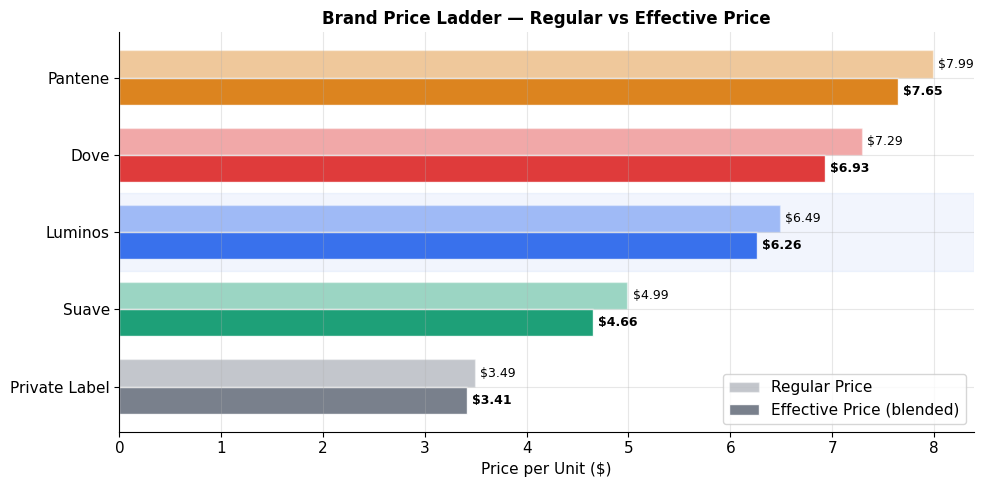

In [4]:
# Chart: price ladder — regular vs effective price
brands_by_price = price_summary.sort_values('regular_price', ascending=True)['brand'].tolist()

fig, ax = plt.subplots(figsize=(10, 5))

y = np.arange(len(brands_by_price))
width = 0.35

reg_vals = [price_summary[price_summary['brand'] == b]['regular_price'].values[0] for b in brands_by_price]
eff_vals = [price_summary[price_summary['brand'] == b]['avg_effective_price'].values[0] for b in brands_by_price]
colors   = [BRAND_COLORS[b] for b in brands_by_price]

bars1 = ax.barh(y + width/2, reg_vals, width, color=colors, alpha=0.4, edgecolor='white', label='Regular Price')
bars2 = ax.barh(y - width/2, eff_vals, width, color=colors, alpha=0.9, edgecolor='white', label='Effective Price (blended)')

for bar, val in zip(bars1, reg_vals):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'${val:.2f}', va='center', fontsize=9)
for bar, val in zip(bars2, eff_vals):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'${val:.2f}', va='center', fontsize=9, fontweight='bold')

ax.set_yticks(y)
ax.set_yticklabels(brands_by_price)
ax.set_xlabel('Price per Unit ($)')
ax.set_title('Brand Price Ladder — Regular vs Effective Price', fontsize=12, fontweight='bold')
ax.legend()

# Highlight Luminos
luminos_idx = brands_by_price.index('Luminos')
ax.axhspan(luminos_idx - 0.5, luminos_idx + 0.5, alpha=0.06, color='#2563EB')

plt.tight_layout()
plt.savefig('../outputs/03_price_ladder.png', dpi=150, bbox_inches='tight')
plt.show()

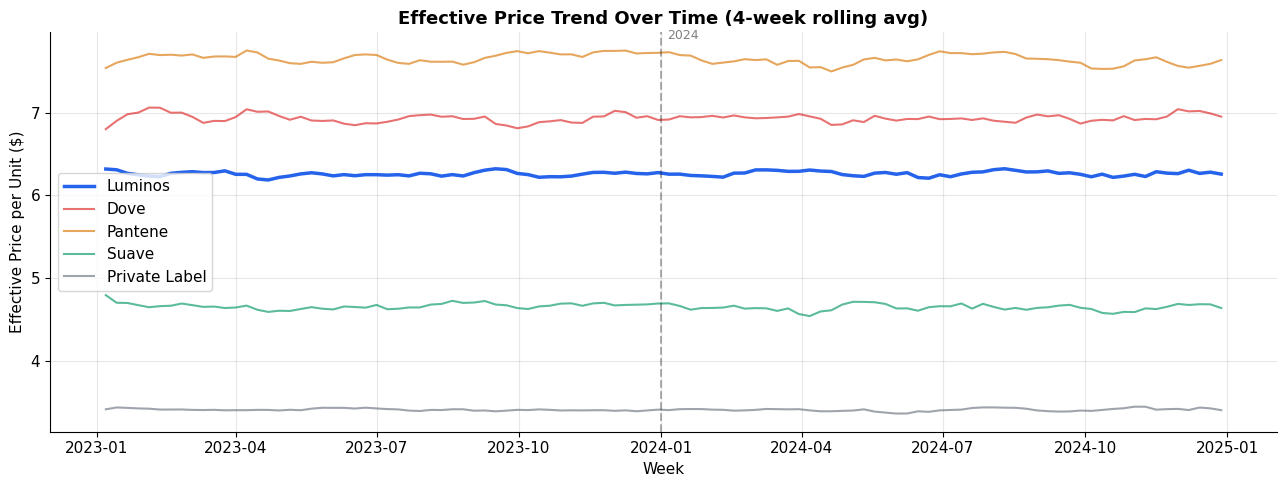

In [5]:
# Effective price trend over time (4-week rolling avg)
price_trend = (
    df.groupby(['week_end_date', 'brand'])['effective_price']
    .mean()
    .reset_index()
    .sort_values(['brand', 'week_end_date'])
)
price_trend['price_4w_ma'] = (
    price_trend.groupby('brand')['effective_price']
    .transform(lambda x: x.rolling(4, min_periods=1).mean())
)

fig, ax = plt.subplots(figsize=(13, 5))

for brand in ['Luminos', 'Dove', 'Pantene', 'Suave', 'Private Label']:
    sub = price_trend[price_trend['brand'] == brand]
    lw  = 2.5 if brand == 'Luminos' else 1.5
    ax.plot(sub['week_end_date'], sub['price_4w_ma'],
            color=BRAND_COLORS[brand], label=brand, linewidth=lw,
            alpha=1.0 if brand == 'Luminos' else 0.65)

ax.axvline(pd.Timestamp('2024-01-01'), color='black', linestyle='--', alpha=0.3)
ax.text(pd.Timestamp('2024-01-05'), ax.get_ylim()[1] * 0.99, '2024', fontsize=9, color='gray')
ax.set_title('Effective Price Trend Over Time (4-week rolling avg)', fontsize=13, fontweight='bold')
ax.set_xlabel('Week')
ax.set_ylabel('Effective Price per Unit ($)')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/03_price_trend.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Price gap = Luminos effective price minus competitor effective price
# Negative = Luminos is cheaper; positive = Luminos is more expensive

price_by_market = (
    df.groupby(['market', 'market_type', 'brand'])['effective_price']
    .mean()
    .reset_index()
)

luminos_price = price_by_market[price_by_market['brand'] == 'Luminos'][['market', 'effective_price']]\
    .rename(columns={'effective_price': 'luminos_price'})

price_gap = price_by_market[price_by_market['brand'] != 'Luminos'].merge(
    luminos_price, on='market'
)
price_gap['price_gap'] = price_gap['luminos_price'] - price_gap['effective_price']

# Focus on Dove (market leader) gap by market type
dove_gap = (
    price_gap[price_gap['brand'] == 'Dove']
    .groupby('market_type')['price_gap']
    .mean()
    .reset_index()
)

print('Luminos vs Dove Price Gap by Market Type (avg effective price difference):')
print('Negative = Luminos is cheaper than Dove')
print()
for _, row in dove_gap.iterrows():
    direction = 'cheaper' if row['price_gap'] < 0 else 'more expensive'
    print(f"  {row['market_type']:<12}: ${row['price_gap']:+.3f} (Luminos is ${abs(row['price_gap']):.2f} {direction} than Dove)")

print()

# Full competitor gap table
full_gap = (
    price_gap
    .groupby(['market_type', 'brand'])['price_gap']
    .mean()
    .unstack('brand')
    .round(3)
)
print('Luminos Price Gap vs All Competitors by Market Type ($):')
print('(Negative = Luminos cheaper, Positive = Luminos more expensive)')
print(full_gap.to_string())

Luminos vs Dove Price Gap by Market Type (avg effective price difference):
Negative = Luminos is cheaper than Dove

  declining   : $-0.657 (Luminos is $0.66 cheaper than Dove)
  growing     : $-0.680 (Luminos is $0.68 cheaper than Dove)
  stable      : $-0.689 (Luminos is $0.69 cheaper than Dove)

Luminos Price Gap vs All Competitors by Market Type ($):
(Negative = Luminos cheaper, Positive = Luminos more expensive)
brand         Dove  Pantene  Private Label  Suave
market_type                                      
declining   -0.657   -1.383          2.840  1.604
growing     -0.680   -1.394          2.850  1.604
stable      -0.689   -1.389          2.859  1.615


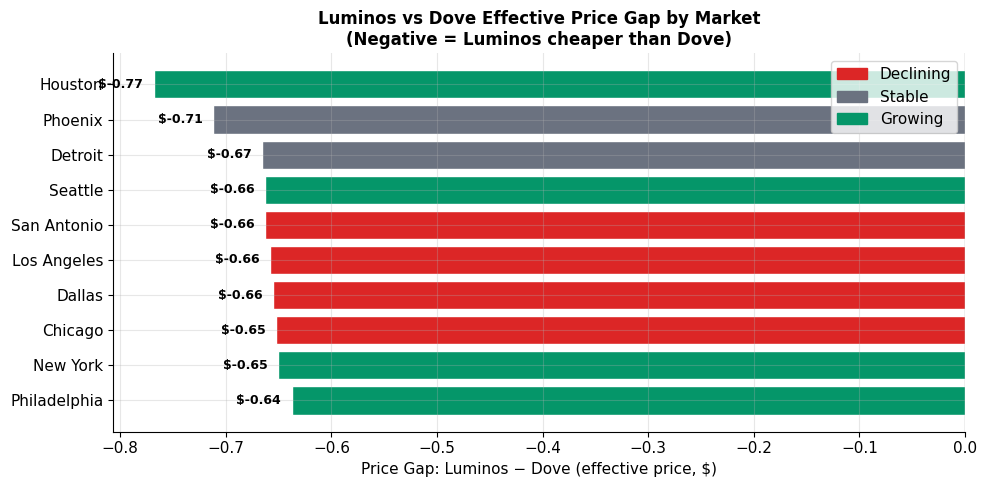

In [7]:
# Price gap chart: Luminos vs Dove by market, colored by type
dove_gap_by_mkt = (
    price_gap[price_gap['brand'] == 'Dove'][['market', 'market_type', 'price_gap']]
    .sort_values('price_gap')
)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [MARKET_TYPE_COLORS[t] for t in dove_gap_by_mkt['market_type']]
bars = ax.barh(dove_gap_by_mkt['market'], dove_gap_by_mkt['price_gap'], color=colors, edgecolor='white')

for bar, val in zip(bars, dove_gap_by_mkt['price_gap']):
    x = bar.get_width() + (0.01 if val >= 0 else -0.01)
    ax.text(x, bar.get_y() + bar.get_height()/2,
            f'${val:+.2f}', va='center', ha='left' if val >= 0 else 'right',
            fontsize=9, fontweight='bold')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Price Gap: Luminos − Dove (effective price, $)')
ax.set_title('Luminos vs Dove Effective Price Gap by Market\n(Negative = Luminos cheaper than Dove)',
             fontsize=12, fontweight='bold')

patches = [mpatches.Patch(color=MARKET_TYPE_COLORS[t], label=t.capitalize())
           for t in ['declining', 'stable', 'growing']]
ax.legend(handles=patches)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/03_price_gap_by_market.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Promo frequency and depth by brand (national)
promo_summary = (
    df.groupby('brand')
    .agg(
        promo_freq  = ('on_promo', 'mean'),
        avg_depth   = ('promo_depth_pct', lambda x: x[x > 0].mean()),  # depth when on promo only
        pct_on_promo_sales = ('pct_sales_on_promo', 'mean'),
    )
    .reset_index()
    .sort_values('promo_freq', ascending=False)
)

print('Promotional Activity by Brand (national avg):')
print('─' * 65)
print(f'{"Brand":<15} {"Promo Freq %":>12} {"Avg Depth %":>12} {"% Sales on Promo":>17}')
print('─' * 65)
for _, row in promo_summary.iterrows():
    print(f"{row['brand']:<15} {row['promo_freq']:>11.1%} {row['avg_depth']:>11.1%} "
          f"{row['pct_on_promo_sales']:>16.1%}")
print('─' * 65)

Promotional Activity by Brand (national avg):
─────────────────────────────────────────────────────────────────
Brand           Promo Freq %  Avg Depth %  % Sales on Promo
─────────────────────────────────────────────────────────────────
Suave                 38.5%       17.4%            26.8%
Dove                  31.8%       15.4%            22.2%
Pantene               30.2%       14.1%            21.3%
Luminos               27.8%       12.7%            19.6%
Private Label         20.8%       10.5%            14.5%
─────────────────────────────────────────────────────────────────


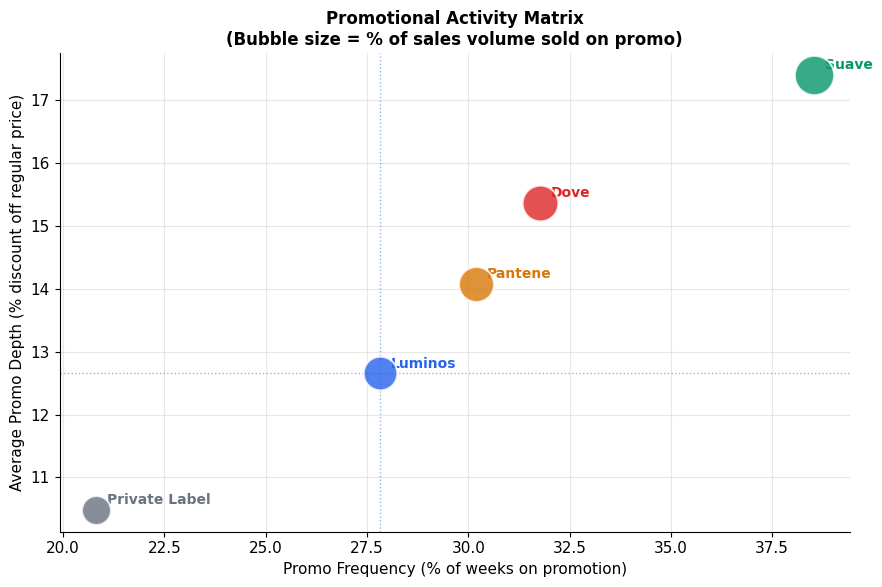

In [9]:
# Chart: promo frequency vs depth bubble chart
fig, ax = plt.subplots(figsize=(9, 6))

for _, row in promo_summary.iterrows():
    brand  = row['brand']
    color  = BRAND_COLORS[brand]
    size   = row['pct_on_promo_sales'] * 3000
    ax.scatter(row['promo_freq'] * 100, row['avg_depth'] * 100,
               s=size, color=color, alpha=0.8, edgecolors='white', linewidths=1.5, zorder=5)
    ax.annotate(brand,
                xy=(row['promo_freq'] * 100, row['avg_depth'] * 100),
                xytext=(8, 4), textcoords='offset points',
                fontsize=10, fontweight='bold', color=color)

# Luminos crosshairs
lum = promo_summary[promo_summary['brand'] == 'Luminos'].iloc[0]
ax.axvline(lum['promo_freq'] * 100, color='#2563EB', linewidth=1, linestyle=':', alpha=0.5)
ax.axhline(lum['avg_depth'] * 100,  color='#2563EB', linewidth=1, linestyle=':', alpha=0.5)

ax.set_xlabel('Promo Frequency (% of weeks on promotion)', fontsize=11)
ax.set_ylabel('Average Promo Depth (% discount off regular price)', fontsize=11)
ax.set_title('Promotional Activity Matrix\n(Bubble size = % of sales volume sold on promo)',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/03_promo_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Luminos promo frequency by market (Y1 vs Y2)
luminos_df = df[df['brand'] == 'Luminos'].copy()
luminos_df['year'] = luminos_df['week_index'].apply(lambda x: 'Y1' if x < 52 else 'Y2')

promo_by_market = (
    luminos_df.groupby(['market', 'market_type', 'year'])
    .agg(
        promo_freq = ('on_promo', 'mean'),
        avg_depth  = ('promo_depth_pct', lambda x: x[x > 0].mean()),
    )
    .unstack('year')
    .reset_index()
)
promo_by_market.columns = ['market', 'market_type',
                            'promo_freq_Y1', 'promo_freq_Y2',
                            'avg_depth_Y1',  'avg_depth_Y2']
promo_by_market['freq_change_pp'] = (
    (promo_by_market['promo_freq_Y2'] - promo_by_market['promo_freq_Y1']) * 100
)
promo_by_market = promo_by_market.sort_values('freq_change_pp')

print('Luminos Promo Frequency: Y1 vs Y2 by Market')
print('─' * 70)
print(f'{"Market":<15} {"Type":<12} {"Y1 Freq":>8} {"Y2 Freq":>8} {"Δ pp":>8} {"Y1 Depth":>9} {"Y2 Depth":>9}')
print('─' * 70)
for _, row in promo_by_market.iterrows():
    print(f"{row['market']:<15} {row['market_type']:<12} "
          f"{row['promo_freq_Y1']:>7.1%} {row['promo_freq_Y2']:>8.1%} "
          f"{row['freq_change_pp']:>+7.1f} "
          f"{row['avg_depth_Y1']:>8.1%} {row['avg_depth_Y2']:>9.1%}")
print('─' * 70)

Luminos Promo Frequency: Y1 vs Y2 by Market
──────────────────────────────────────────────────────────────────────
Market          Type          Y1 Freq  Y2 Freq     Δ pp  Y1 Depth  Y2 Depth
──────────────────────────────────────────────────────────────────────
Detroit         stable         30.1%    23.1%    -7.1    12.5%     12.3%
Philadelphia    growing        26.3%    21.2%    -5.1    12.5%     12.5%
Dallas          declining      29.5%    25.0%    -4.5    12.8%     12.7%
Los Angeles     declining      29.5%    25.6%    -3.8    12.6%     13.1%
New York        growing        28.2%    25.6%    -2.6    12.8%     12.4%
Phoenix         stable         27.6%    26.9%    -0.6    12.8%     12.8%
Chicago         declining      28.8%    31.4%    +2.6    12.7%     12.5%
San Antonio     declining      27.6%    30.8%    +3.2    12.8%     12.3%
Houston         growing        28.2%    32.7%    +4.5    13.1%     12.3%
Seattle         growing        25.0%    33.3%    +8.3    13.2%     12.5%
────────

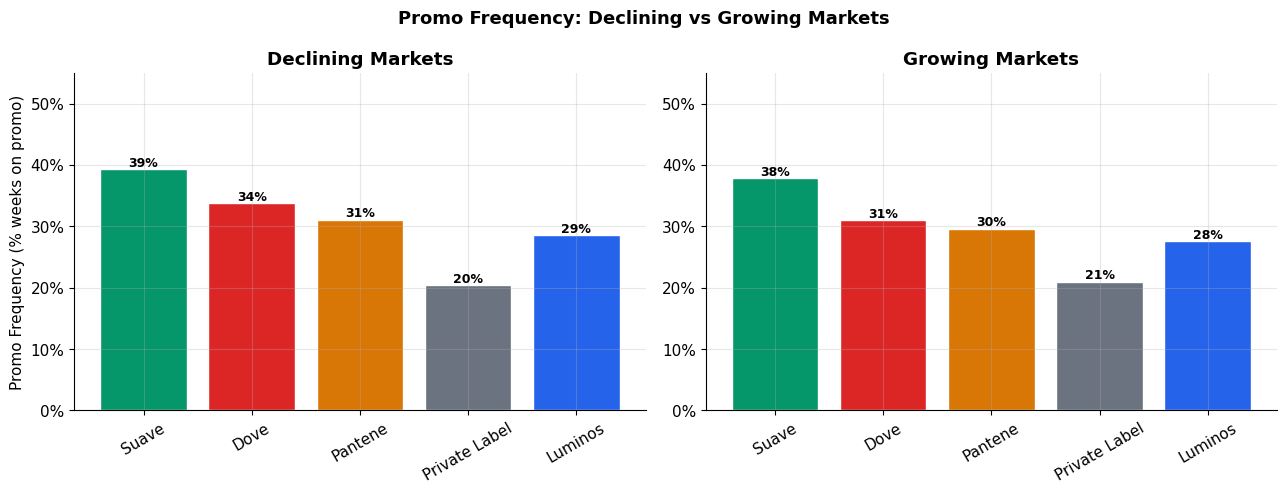

In [11]:
# Competitor promo frequency in declining markets vs growing markets
comp_promo_by_type = (
    df.groupby(['brand', 'market_type'])['on_promo']
    .mean()
    .unstack('market_type')
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Promo Frequency: Declining vs Growing Markets', fontsize=13, fontweight='bold')

brands_ordered = ['Suave', 'Dove', 'Pantene', 'Private Label', 'Luminos']

for ax, mtype, title in zip(axes, ['declining', 'growing'], ['Declining Markets', 'Growing Markets']):
    vals   = [comp_promo_by_type[comp_promo_by_type['brand'] == b][mtype].values[0]
              if mtype in comp_promo_by_type.columns else 0 for b in brands_ordered]
    colors = [BRAND_COLORS[b] for b in brands_ordered]
    bars   = ax.bar(brands_ordered, vals, color=colors, edgecolor='white')

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.0%}', ha='center', fontsize=9, fontweight='bold')

    ax.set_title(title, fontweight='bold')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_ylim(0, 0.55)
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylabel('Promo Frequency (% weeks on promo)' if mtype == 'declining' else '')

plt.tight_layout()
plt.savefig('../outputs/03_promo_freq_by_market_type.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Compute promo lift: avg units on-promo / avg units off-promo per brand × market
promo_lift = (
    df.groupby(['brand', 'on_promo'])['unit_sales']
    .mean()
    .unstack('on_promo')
    .rename(columns={False: 'units_off_promo', True: 'units_on_promo'})
    .assign(promo_lift=lambda x: x['units_on_promo'] / x['units_off_promo'])
    .reset_index()
    .sort_values('promo_lift', ascending=False)
)

print('Promo Lift by Brand (national, units on-promo / units off-promo):')
print('─' * 60)
print(f'{"Brand":<15} {"Off-Promo Units":>15} {"On-Promo Units":>15} {"Lift":>8}')
print('─' * 60)
for _, row in promo_lift.iterrows():
    print(f"{row['brand']:<15} {row['units_off_promo']:>15,.1f} "
          f"{row['units_on_promo']:>15,.1f} {row['promo_lift']:>7.2f}x")
print('─' * 60)

Promo Lift by Brand (national, units on-promo / units off-promo):
────────────────────────────────────────────────────────────
Brand           Off-Promo Units  On-Promo Units     Lift
────────────────────────────────────────────────────────────
Dove                      464.9           860.3    1.85x
Suave                     440.7           774.8    1.76x
Pantene                   351.8           606.4    1.72x
Luminos                   273.4           421.0    1.54x
Private Label             432.8           575.6    1.33x
────────────────────────────────────────────────────────────


In [13]:
# Promo lift by market type for Luminos
luminos_lift_by_type = (
    df[df['brand'] == 'Luminos']
    .groupby(['market_type', 'on_promo'])['unit_sales']
    .mean()
    .unstack('on_promo')
    .rename(columns={False: 'off_promo', True: 'on_promo'})
    .assign(lift=lambda x: x['on_promo'] / x['off_promo'])
    .reset_index()
)

print('Luminos Promo Lift by Market Type:')
print(luminos_lift_by_type[['market_type', 'off_promo', 'on_promo', 'lift']]
      .to_string(index=False, float_format='{:.2f}'.format))

Luminos Promo Lift by Market Type:
market_type  off_promo  on_promo  lift
  declining     253.25    383.54  1.51
    growing     289.50    446.66  1.54
     stable     280.81    447.79  1.59


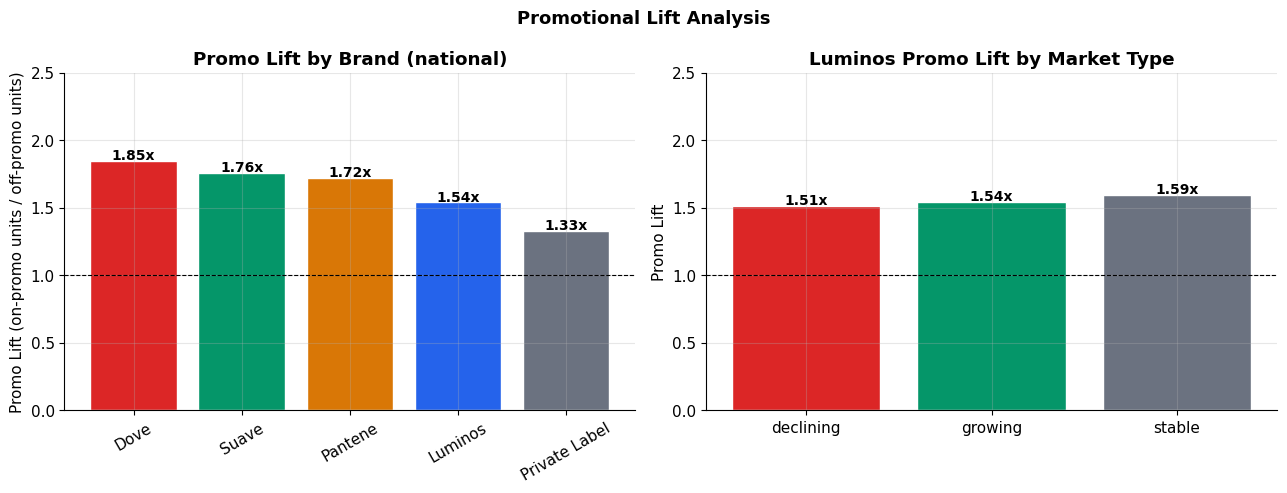

In [14]:
# Chart: promo lift comparison across brands
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Promotional Lift Analysis', fontsize=13, fontweight='bold')

# Left: lift by brand
ax = axes[0]
colors = [BRAND_COLORS[b] for b in promo_lift['brand']]
bars = ax.bar(promo_lift['brand'], promo_lift['promo_lift'], color=colors, edgecolor='white')
ax.axhline(1.0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars, promo_lift['promo_lift']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}x', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Promo Lift by Brand (national)', fontweight='bold')
ax.set_ylabel('Promo Lift (on-promo units / off-promo units)')
ax.tick_params(axis='x', rotation=30)
ax.set_ylim(0, 2.5)

# Right: Luminos lift by market type
ax = axes[1]
type_colors = [MARKET_TYPE_COLORS[t] for t in luminos_lift_by_type['market_type']]
bars = ax.bar(luminos_lift_by_type['market_type'], luminos_lift_by_type['lift'],
              color=type_colors, edgecolor='white')
ax.axhline(1.0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars, luminos_lift_by_type['lift']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}x', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Luminos Promo Lift by Market Type', fontweight='bold')
ax.set_ylabel('Promo Lift')
ax.set_ylim(0, 2.5)

plt.tight_layout()
plt.savefig('../outputs/03_promo_lift.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Log-log OLS regression: ln(unit_sales) ~ ln(effective_price)
# Slope = price elasticity
# Run separately for each market type

luminos_all = df[df['brand'] == 'Luminos'].copy()
luminos_all['log_units'] = np.log(luminos_all['unit_sales'].clip(lower=0.01))
luminos_all['log_price'] = np.log(luminos_all['effective_price'])

elasticity_results = []

for mtype in ['declining', 'stable', 'growing']:
    sub = luminos_all[luminos_all['market_type'] == mtype]
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        sub['log_price'], sub['log_units']
    )
    elasticity_results.append({
        'market_type':  mtype,
        'elasticity':   round(slope, 3),
        'r_squared':    round(r_value**2, 3),
        'p_value':      round(p_value, 4),
        'n_obs':        len(sub),
    })

# National elasticity
slope_nat, _, r_nat, p_nat, _ = stats.linregress(
    luminos_all['log_price'], luminos_all['log_units']
)
elasticity_results.append({
    'market_type': 'national',
    'elasticity':  round(slope_nat, 3),
    'r_squared':   round(r_nat**2, 3),
    'p_value':     round(p_nat, 4),
    'n_obs':       len(luminos_all),
})

elas_df = pd.DataFrame(elasticity_results)

print('Luminos Price Elasticity of Demand (log-log OLS):')
print('─' * 60)
print(f'{"Market Type":<15} {"Elasticity":>12} {"R²":>8} {"p-value":>10} {"N obs":>8}')
print('─' * 60)
for _, row in elas_df.iterrows():
    interp = 'elastic' if row['elasticity'] < -1 else 'inelastic'
    print(f"{row['market_type']:<15} {row['elasticity']:>12.3f} "
          f"{row['r_squared']:>8.3f} {row['p_value']:>10.4f} "
          f"{row['n_obs']:>8,}  ({interp})")
print('─' * 60)

Luminos Price Elasticity of Demand (log-log OLS):
────────────────────────────────────────────────────────────
Market Type       Elasticity       R²    p-value    N obs
────────────────────────────────────────────────────────────
declining             -3.018    0.212     0.0000    1,248  (elastic)
stable                -3.483    0.258     0.0000      624  (elastic)
growing               -3.140    0.225     0.0000    1,248  (elastic)
national              -3.143    0.219     0.0000    3,120  (elastic)
────────────────────────────────────────────────────────────


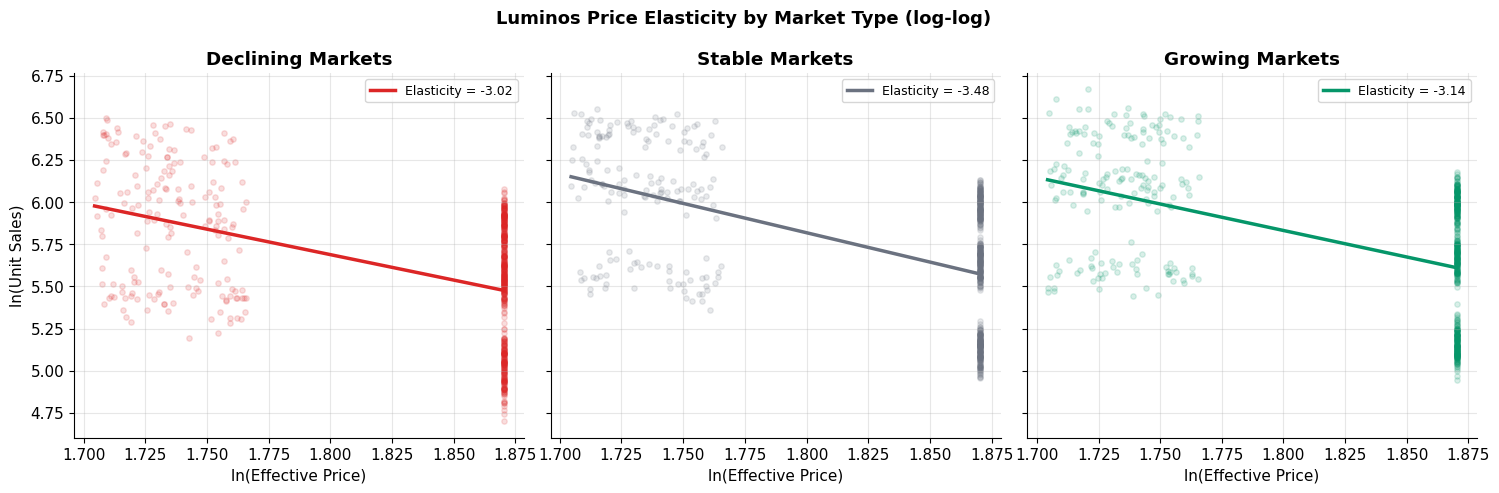

In [16]:
# Scatter: log price vs log units for Luminos (national)
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle('Luminos Price Elasticity by Market Type (log-log)', fontsize=13, fontweight='bold')

for ax, mtype in zip(axes, ['declining', 'stable', 'growing']):
    sub = luminos_all[luminos_all['market_type'] == mtype].sample(
        min(600, len(luminos_all[luminos_all['market_type'] == mtype])), random_state=42
    )
    ax.scatter(sub['log_price'], sub['log_units'],
               alpha=0.15, s=15, color=MARKET_TYPE_COLORS[mtype])

    # Regression line
    x_range = np.linspace(sub['log_price'].min(), sub['log_price'].max(), 100)
    row = elas_df[elas_df['market_type'] == mtype].iloc[0]
    y_fit = row['elasticity'] * x_range + np.mean(sub['log_units']) - row['elasticity'] * np.mean(sub['log_price'])
    ax.plot(x_range, y_fit, color=MARKET_TYPE_COLORS[mtype], linewidth=2.5,
            label=f'Elasticity = {row["elasticity"]:.2f}')

    ax.set_title(f'{mtype.capitalize()} Markets', fontweight='bold')
    ax.set_xlabel('ln(Effective Price)')
    ax.set_ylabel('ln(Unit Sales)' if mtype == 'declining' else '')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/03_price_elasticity.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Luminos price & promo summary by market type
luminos_df['year'] = luminos_df['week_index'].apply(lambda x: 'Y1' if x < 52 else 'Y2')

summary_by_type = (
    luminos_df.groupby('market_type')
    .agg(
        avg_regular_price  = ('regular_price', 'mean'),
        avg_effective_price= ('effective_price', 'mean'),
        promo_freq         = ('on_promo', 'mean'),
        avg_promo_depth    = ('promo_depth_pct', lambda x: x[x > 0].mean()),
        pct_sales_on_promo = ('pct_sales_on_promo', 'mean'),
    )
    .reset_index()
)

# Merge in velocity change from diagnostic
vel_by_type = (
    diagnostic.groupby('market_type')['vel_change_pct'].mean().reset_index()
)
summary_by_type = summary_by_type.merge(vel_by_type, on='market_type', how='left')

print('Integrated Price & Promo Summary by Market Type (Luminos):')
print('─' * 85)
cols = ['market_type','avg_regular_price','avg_effective_price',
        'promo_freq','avg_promo_depth','pct_sales_on_promo','vel_change_pct']
headers = ['Type','Reg Price','Eff Price','Promo Freq','Depth','% Sales Promo','Vel Chg %']
print('  '.join(f'{h:>13}' for h in headers))
print('─' * 85)
for _, row in summary_by_type.iterrows():
    vel = f"{row['vel_change_pct']:+.1f}%" if pd.notna(row['vel_change_pct']) else 'N/A'
    print(f"  {row['market_type']:<11}  ${row['avg_regular_price']:.2f}       "
          f"${row['avg_effective_price']:.2f}     {row['promo_freq']:.1%}   "
          f"  {row['avg_promo_depth']:.1%}       {row['pct_sales_on_promo']:.1%}      {vel}")
print('─' * 85)

Integrated Price & Promo Summary by Market Type (Luminos):
─────────────────────────────────────────────────────────────────────────────────────
         Type      Reg Price      Eff Price     Promo Freq          Depth  % Sales Promo      Vel Chg %
─────────────────────────────────────────────────────────────────────────────────────
  declining    $6.49       $6.26     28.5%     12.7%       20.1%      -4.3%
  growing      $6.49       $6.26     27.6%     12.7%       19.4%      +2.8%
  stable       $6.49       $6.27     26.9%     12.6%       18.9%      -0.1%
─────────────────────────────────────────────────────────────────────────────────────


In [18]:
# Auto-generate findings
luminos_reg  = price_summary[price_summary['brand'] == 'Luminos']['regular_price'].values[0]
dove_reg     = price_summary[price_summary['brand'] == 'Dove']['regular_price'].values[0]
suave_reg    = price_summary[price_summary['brand'] == 'Suave']['regular_price'].values[0]
luminos_disc = price_summary[price_summary['brand'] == 'Luminos']['avg_discount_pct'].values[0]
dove_disc    = price_summary[price_summary['brand'] == 'Dove']['avg_discount_pct'].values[0]
suave_disc   = price_summary[price_summary['brand'] == 'Suave']['avg_discount_pct'].values[0]

luminos_promo_freq = promo_summary[promo_summary['brand'] == 'Luminos']['promo_freq'].values[0]
suave_promo_freq   = promo_summary[promo_summary['brand'] == 'Suave']['promo_freq'].values[0]
dove_promo_freq    = promo_summary[promo_summary['brand'] == 'Dove']['promo_freq'].values[0]

luminos_lift = promo_lift[promo_lift['brand'] == 'Luminos']['promo_lift'].values[0]
dove_lift    = promo_lift[promo_lift['brand'] == 'Dove']['promo_lift'].values[0]

nat_elasticity = elas_df[elas_df['market_type'] == 'national']['elasticity'].values[0]
dec_elasticity = elas_df[elas_df['market_type'] == 'declining']['elasticity'].values[0]

print('=' * 65)
print('  KEY FINDINGS — Price & Promo Analysis')
print('=' * 65)
print(f"""
1. PRICE POSITIONING
   Luminos (${luminos_reg:.2f}) sits between premium brands
   (Dove ${dove_reg:.2f}, Pantene $7.99) and value brands
   (Suave ${suave_reg:.2f}). It occupies a mid-tier position
   with limited differentiation in either direction.

2. PROMOTIONAL INTENSITY
   Luminos promotes {luminos_promo_freq:.0%} of weeks vs Suave at {suave_promo_freq:.0%}
   and Dove at {dove_promo_freq:.0%}. Luminos is the least frequently
   promoted mid-tier brand — a potential vulnerability
   when Suave is promoting heavily nearby on shelf.

3. PROMO DEPTH
   Luminos discounts {luminos_disc:.1f}% on average when on promo,
   vs Dove at {dove_disc:.1f}% and Suave at {suave_disc:.1f}%. Luminos's
   promo depth is the shallowest of the main brands,
   limiting the consumer incentive to switch in.

4. PROMO LIFT
   Luminos achieves {luminos_lift:.2f}x unit lift on promotion vs
   Dove at {dove_lift:.2f}x. Promotions do drive volume for Luminos,
   but it promotes less often and less deeply than
   key competitors.

5. PRICE ELASTICITY
   National elasticity = {nat_elasticity:.2f} (elastic — consumers
   are price-sensitive). In declining markets, elasticity
   = {dec_elasticity:.2f}, meaning a 1% price reduction drives
   ~{abs(dec_elasticity):.1f}% more units. Promotions have real impact.

6. STRATEGIC IMPLICATION
   The combination of mid-tier pricing, below-market promo
   frequency, and shallow promo depth means Luminos is
   giving consumers in declining markets no compelling
   reason to choose it over Suave (value) or Dove (premium).
   Recommendation: increase promo frequency in the 3 most
   severely declining markets (San Antonio, Dallas, Chicago)
   and test a deeper promo depth (22–25%) to match Dove's
   promotional investment.
""")
print('=' * 65)

  KEY FINDINGS — Price & Promo Analysis

1. PRICE POSITIONING
   Luminos ($6.49) sits between premium brands
   (Dove $7.29, Pantene $7.99) and value brands
   (Suave $4.99). It occupies a mid-tier position
   with limited differentiation in either direction.

2. PROMOTIONAL INTENSITY
   Luminos promotes 28% of weeks vs Suave at 39%
   and Dove at 32%. Luminos is the least frequently
   promoted mid-tier brand — a potential vulnerability
   when Suave is promoting heavily nearby on shelf.

3. PROMO DEPTH
   Luminos discounts 3.5% on average when on promo,
   vs Dove at 4.9% and Suave at 6.7%. Luminos's
   promo depth is the shallowest of the main brands,
   limiting the consumer incentive to switch in.

4. PROMO LIFT
   Luminos achieves 1.54x unit lift on promotion vs
   Dove at 1.85x. Promotions do drive volume for Luminos,
   but it promotes less often and less deeply than
   key competitors.

5. PRICE ELASTICITY
   National elasticity = -3.14 (elastic — consumers
   are price-sensit

In [19]:
# Save final integrated summary
final_summary = diagnostic.merge(
    summary_by_type[['market_type','promo_freq','avg_promo_depth','avg_effective_price']],
    on='market_type', how='left'
)
final_summary.to_csv('../data/nielsen_final_summary.csv', index=False)
print('Saved: ../data/nielsen_final_summary.csv')
print()
print('Nielsen analysis complete.')
print('All 3 notebooks tell a connected story:')
print('  01: WHERE Luminos is losing share (4 markets)')
print('  02: WHY — both ACV and velocity declining')
print('  03: ROOT CAUSE — under-promoting vs competitors at mid-tier price')

Saved: ../data/nielsen_final_summary.csv

Nielsen analysis complete.
All 3 notebooks tell a connected story:
  01: WHERE Luminos is losing share (4 markets)
  02: WHY — both ACV and velocity declining
  03: ROOT CAUSE — under-promoting vs competitors at mid-tier price
